In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model

In [2]:


# ====================
# Settings
# ====================
DATA_DIR = "C:\\Users\\peter\\Documents\\internship\\DATASET"
IMG_SIZE = (224, 224)
BATCH_SIZE = 128
SEED = 42
EPOCHS = 50
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

# ====================
# Load full dataset
# ====================
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    label_mode='categorical',   # one-hot labels
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)



Found 1203 files belonging to 4 classes.


In [9]:
# ====================
# Compute dataset sizes for split
# ====================
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
test_size = int(TEST_SPLIT * dataset_size)
train_val_size = dataset_size - test_size
val_size = int(VAL_SPLIT * train_val_size)
train_size = train_val_size - val_size

# ====================
# Split into train/val/test
# ====================
train_val_ds = full_ds.take(train_val_size)
test_ds = full_ds.skip(train_val_size)

val_ds = train_val_ds.take(val_size)
train_ds = train_val_ds.skip(val_size)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ====================
# Data augmentation
# ====================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
# ====================
# Callbacks
# ====================
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)




In [4]:
# ====================
# EfficientNetB0 base
# ====================
base_model = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze base


# ====================
# Build model
# ====================
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)  # batch norm after dense
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = models.Model(inputs, outputs)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3988 - loss: 1.9316
Epoch 1: val_accuracy improved from None to 0.71875, saving model to best_modelNT.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5459 - loss: 1.3927 - val_accuracy: 0.7188 - val_loss: 0.7890
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7606 - loss: 0.7013
Epoch 2: val_accuracy improved from 0.71875 to 0.75781, saving model to best_modelNT.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7773 - loss: 0.6658 - val_accuracy: 0.7578 - val_loss: 0.6398
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8449 - loss: 0.4653
Epoch 3: val_accuracy improved from 0.75781 to 0.79688, saving model to best_modelNT.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8242 - loss: 0.5249 - val_accuracy: 0.7969 - val_loss: 0.6391
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8402 - loss: 0.4322
Epoch 4: val_accuracy improved from 0.79688 to 0.81250, saving mode

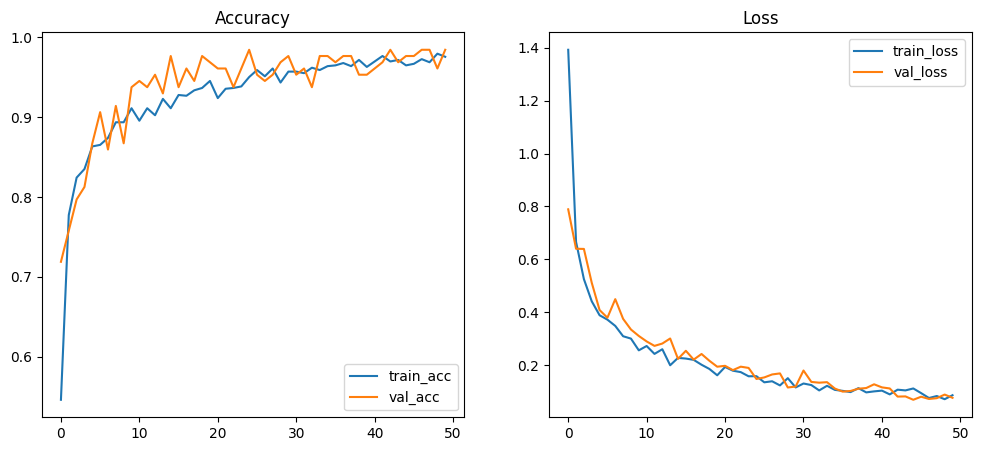

In [ ]:
# ====================
# Compile model
# ====================
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ====================
# Train
# ====================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

# ====================
# Plot accuracy/loss
# ====================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.show()



In [6]:
best_model = load_model("best_modelNT.keras")
best_model.save("model_normaltraining.keras")

In [6]:
model = load_model("model_normaltraining.keras")
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# ====================
# Evaluate on test set
# ====================
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9804 - loss: 0.1814
Test Accuracy: 0.9803921580314636


Classes: ['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 448ms/step


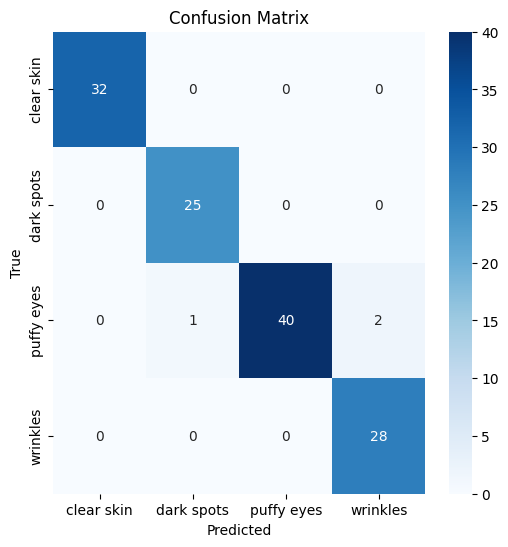

In [8]:
# 2️⃣ Get class names from your folder structure
DATA_DIR = "C:\\Users\\peter\\Documents\\internship\\DATASET"
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes:", class_names)
# 3️⃣ Collect all test images and labels
test_images, test_labels = [], []

for images, labels in val_ds:  # or your test_ds
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.vstack(test_images)
test_labels = np.vstack(test_labels)

# 4️⃣ Predict classes
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# 5️⃣ Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
